# AutoQuant — Market Data & Technical Analysis Demo

A tour of the `autoquant` package: pull **current** and **historical** prices,
compute the classic technical metrics (**moving averages**, **momentum**, **mean
reversion**, volatility), and apply them to popular stocks and to the **S&P 500**.

**Data source.** Pick the provider in the *Configuration* cell via the `ADAPTER`
switch:

* `"yfinance"` — Yahoo Finance, no API key, no request cap (the default here).
* `"alphavantage"` — uses the key in your `.env` (~25 requests/day; responses are
  cached under `.cache/alphavantage/`).

The rest of the notebook is identical either way — that's the point of the adapter.

## 0. Setup

In [1]:
import sys
from pathlib import Path

for _cand in (Path.cwd(), *Path.cwd().parents):
    if (_cand / "autoquant").is_dir():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import autoquant as aq
from autoquant import metrics as m

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("pandas", pd.__version__, "| autoquant", aq.__version__)

pandas 3.0.3 | autoquant 0.2.0


## 1. Configuration

Choose the data source and the symbols to analyse.

In [2]:
ADAPTER = "yfinance"   # "yfinance" (no API key) or "alphavantage" (uses your .env key)
adapter = aq.get_adapter(ADAPTER)

POPULAR = ["AAPL", "MSFT", "NVDA", "AMZN"]
BENCHMARK = "SPY"                 # ETF proxy for the S&P 500 index
UNIVERSE = POPULAR + [BENCHMARK]

print("Data source:", adapter.name)

Data source: yfinance


## 2. Current prices

`get_quotes` returns the latest price, the day's change, and volume per symbol.

In [3]:
quotes = adapter.get_quotes(UNIVERSE)
quotes[["price", "change", "change percent", "volume", "latest trading day"]]

,price,change,change percent,volume,latest trading day
symbol,,,,,
AAPL,308.82,3.83,1.26,43627900,2026-05-22
MSFT,418.57,-0.52,-0.12,22341900,2026-05-22
NVDA,215.33,-4.18,-1.90,168346300,2026-05-22
AMZN,266.32,-2.14,-0.80,27470500,2026-05-22
SPY,745.64,2.92,0.39,41671800,2026-05-22


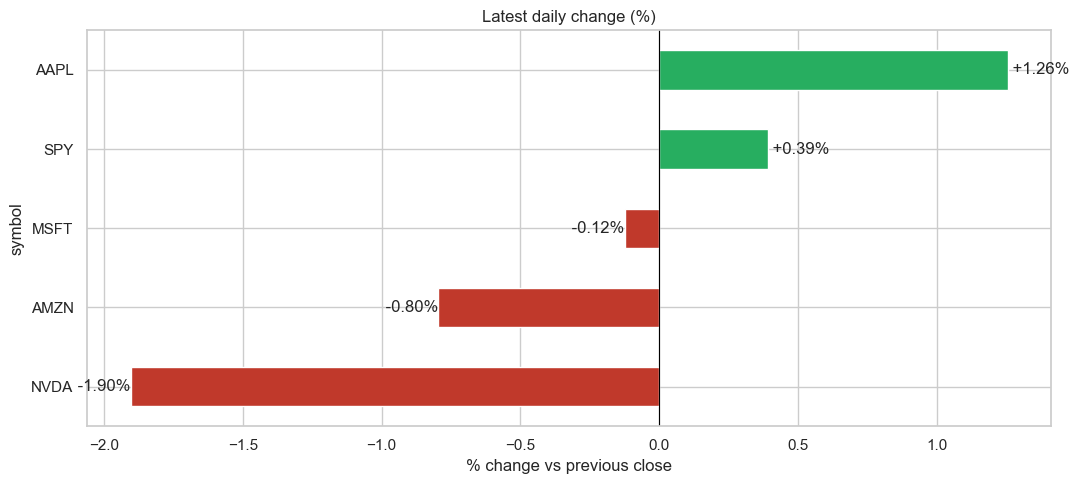

In [4]:
chg = quotes["change percent"].sort_values()
colors = ["#c0392b" if v < 0 else "#27ae60" for v in chg]

ax = chg.plot(kind="barh", color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Latest daily change (%)")
ax.set_xlabel("% change vs previous close")
for i, v in enumerate(chg):
    ax.text(v, i, f" {v:+.2f}%", va="center", ha="left" if v >= 0 else "right")
plt.tight_layout()
plt.show()

## 3. Historical prices & technical indicators

`get_daily` returns an OHLCV frame; `metrics.add_indicators` augments it with a
standard panel of indicators in one call.

In [5]:
daily_data = {sym: adapter.get_daily(sym) for sym in UNIVERSE}
closes = pd.DataFrame({sym: df["close"] for sym, df in daily_data.items()}).sort_index()

aapl = m.add_indicators(daily_data["AAPL"])
print("AAPL daily rows:", len(aapl),
      "| from", aapl.index.min().date(), "to", aapl.index.max().date())
aapl[["close", "sma_20", "sma_50", "rsi_14", "macd", "zscore_20"]].tail()

AAPL daily rows: 251 | from 2025-05-23 to 2026-05-22


,close,sma_20,sma_50,rsi_14,macd,zscore_20
date,,,,,,
2026-05-18,297.84,282.61,266.78,71.67,9.46,1.29
2026-05-19,298.97,284.26,267.57,72.48,9.40,1.26
2026-05-20,302.25,285.73,268.40,74.71,9.50,1.38
2026-05-21,304.99,287.32,269.29,76.44,9.69,1.44
2026-05-22,308.82,289.22,270.36,78.63,10.04,1.56


### 3a. Price, moving averages & Bollinger bands

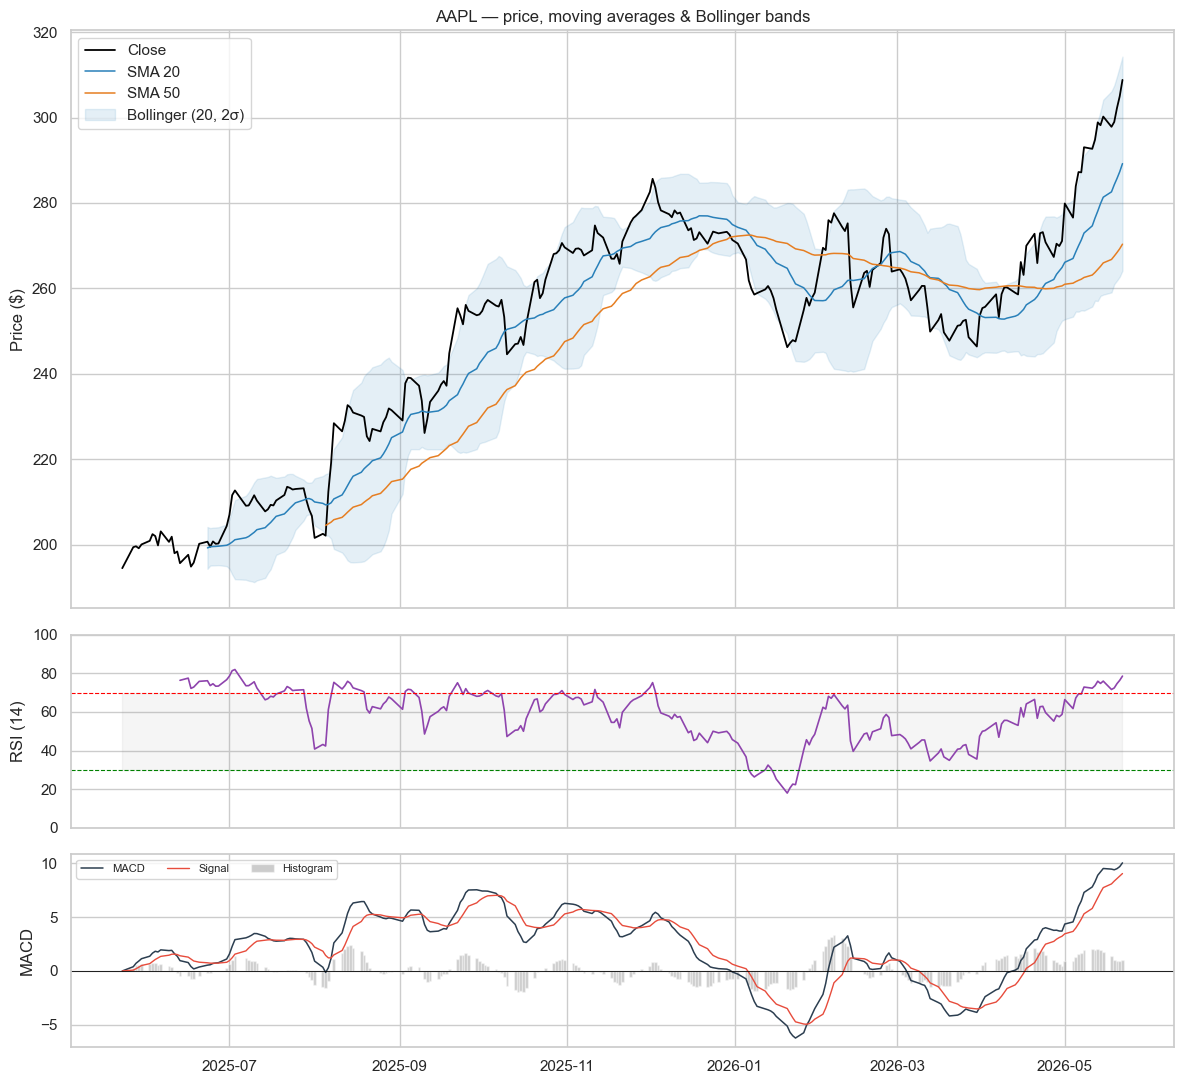

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1, 1]})

ax = axes[0]
ax.plot(aapl.index, aapl["close"], color="black", lw=1.3, label="Close")
ax.plot(aapl.index, aapl["sma_20"], color="#2980b9", lw=1.1, label="SMA 20")
ax.plot(aapl.index, aapl["sma_50"], color="#e67e22", lw=1.1, label="SMA 50")
ax.fill_between(aapl.index, aapl["bb_lower"], aapl["bb_upper"],
                color="#2980b9", alpha=0.12, label="Bollinger (20, 2σ)")
ax.set_title("AAPL — price, moving averages & Bollinger bands")
ax.set_ylabel("Price ($)")
ax.legend(loc="upper left")

ax = axes[1]
ax.plot(aapl.index, aapl["rsi_14"], color="#8e44ad", lw=1.2)
ax.axhline(70, color="red", ls="--", lw=0.8)
ax.axhline(30, color="green", ls="--", lw=0.8)
ax.fill_between(aapl.index, 30, 70, color="grey", alpha=0.08)
ax.set_ylabel("RSI (14)")
ax.set_ylim(0, 100)

ax = axes[2]
ax.plot(aapl.index, aapl["macd"], color="#2c3e50", lw=1.1, label="MACD")
ax.plot(aapl.index, aapl["macd_signal"], color="#e74c3c", lw=1.0, label="Signal")
ax.bar(aapl.index, aapl["macd_hist"], color="grey", alpha=0.4, width=1.0, label="Histogram")
ax.axhline(0, color="black", lw=0.6)
ax.set_ylabel("MACD")
ax.legend(loc="upper left", ncol=3, fontsize=8)

plt.tight_layout()
plt.show()

### 3b. Momentum vs. mean reversion

**Momentum** (10-day rate-of-change) assumes recent direction persists.
**Mean reversion** (20-day z-score) assumes a stretched price snaps back toward
its average; readings beyond ±2 flag unusual extension.

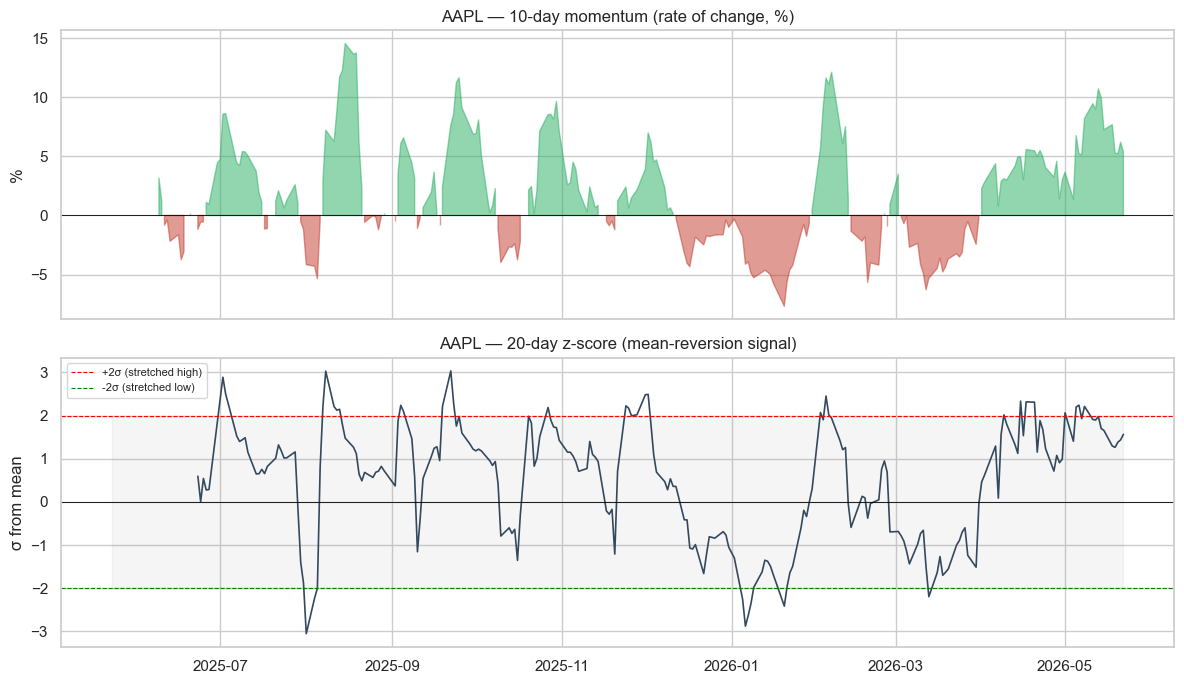

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
mom = aapl["momentum_10"]
ax.fill_between(mom.index, mom, 0, where=mom >= 0, color="#27ae60", alpha=0.5)
ax.fill_between(mom.index, mom, 0, where=mom < 0, color="#c0392b", alpha=0.5)
ax.axhline(0, color="black", lw=0.6)
ax.set_title("AAPL — 10-day momentum (rate of change, %)")
ax.set_ylabel("%")

ax = axes[1]
z = aapl["zscore_20"]
ax.plot(z.index, z, color="#34495e", lw=1.2)
ax.axhline(2, color="red", ls="--", lw=0.8, label="+2σ (stretched high)")
ax.axhline(-2, color="green", ls="--", lw=0.8, label="-2σ (stretched low)")
ax.axhline(0, color="black", lw=0.6)
ax.fill_between(z.index, -2, 2, color="grey", alpha=0.08)
ax.set_title("AAPL — 20-day z-score (mean-reversion signal)")
ax.set_ylabel("σ from mean")
ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## 4. Comparing popular stocks against the S&P 500

Rebasing each series to 100 at the start makes relative performance comparable.

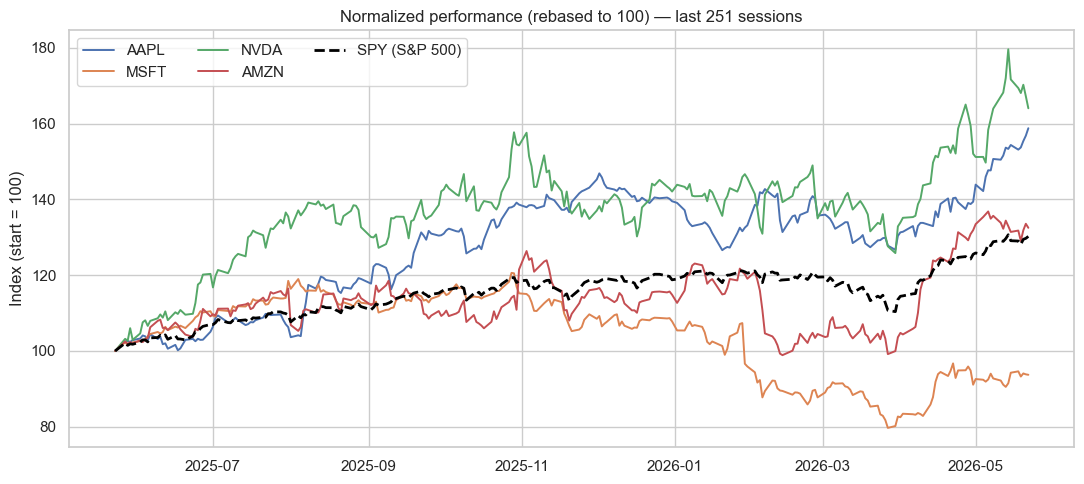

In [8]:
norm = closes.apply(lambda s: s / s.dropna().iloc[0] * 100.0)

ax = plt.gca()
for col in POPULAR:
    ax.plot(norm.index, norm[col], lw=1.4, label=col)
ax.plot(norm.index, norm[BENCHMARK], lw=2.0, color="black", ls="--", label=f"{BENCHMARK} (S&P 500)")
ax.set_title(f"Normalized performance (rebased to 100) — last {len(norm)} sessions")
ax.set_ylabel("Index (start = 100)")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

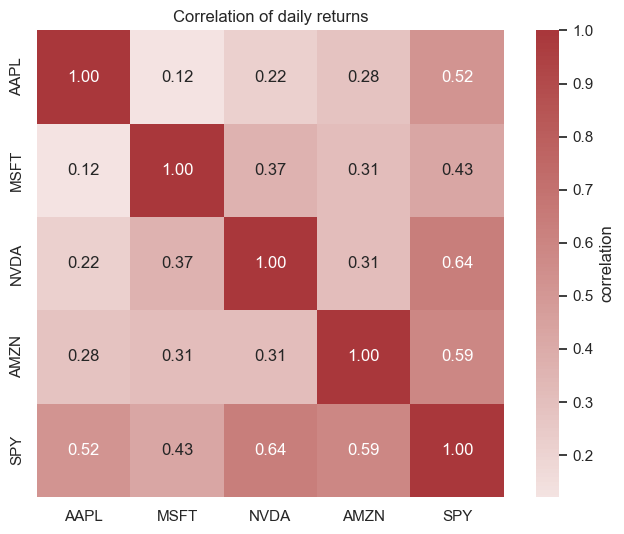

In [9]:
daily_returns = closes.pct_change().dropna()

plt.figure(figsize=(7, 5.5))
sns.heatmap(daily_returns.corr(), annot=True, fmt=".2f", cmap="vlag",
            center=0, square=True, cbar_kws={"label": "correlation"})
plt.title("Correlation of daily returns")
plt.tight_layout()
plt.show()

### 4a. Indicator scoreboard

In [10]:
rows = {}
for sym in UNIVERSE:
    px = daily_data[sym]["close"]
    ret = m.simple_returns(px).dropna()
    rows[sym] = {
        "last_close": px.iloc[-1],
        "mom_20d_%": m.momentum(px, 20).iloc[-1],
        "mom_50d_%": m.momentum(px, 50).iloc[-1],
        "rsi_14": m.rsi(px).iloc[-1],
        "zscore_20": m.rolling_zscore(px, 20).iloc[-1],
        "ann_vol_%": m.annualized_volatility(ret) * 100,
    }

scoreboard = pd.DataFrame(rows).T
(scoreboard.style
    .format("{:,.2f}")
    .background_gradient(subset=["mom_20d_%", "mom_50d_%"], cmap="RdYlGn")
    .background_gradient(subset=["zscore_20"], cmap="coolwarm")
    .set_caption("Momentum / mean-reversion snapshot (daily)"))

,last_close,mom_20d_%,mom_50d_%,rsi_14,zscore_20,ann_vol_%
AAPL,308.82,14.04,20.86,78.63,1.56,22.19
MSFT,418.57,-1.21,4.38,55.11,0.43,23.79
NVDA,215.33,3.39,17.58,53.71,0.06,33.97
AMZN,266.32,0.88,27.10,57.98,-0.18,29.70
SPY,745.64,4.44,12.25,68.86,1.22,12.02


## 5. S&P 500 analysis

For the index we use the **weekly & monthly** endpoints, which return many years of
history — enough to see multiple market cycles. (SPY is the tradable proxy.)

In [11]:
spy_w = adapter.get_weekly(BENCHMARK)
spy_m = adapter.get_monthly(BENCHMARK)

px = spy_w["close"]
wk_ret = m.simple_returns(px).dropna()
years = (px.index[-1] - px.index[0]).days / 365.25
cagr = (px.iloc[-1] / px.iloc[0]) ** (1 / years) - 1

summary = pd.Series({
    "start": px.index[0].date(),
    "end": px.index[-1].date(),
    "years": round(years, 1),
    "start_price": round(px.iloc[0], 2),
    "last_price": round(px.iloc[-1], 2),
    "total_return_%": round((px.iloc[-1] / px.iloc[0] - 1) * 100, 1),
    "CAGR_%": round(cagr * 100, 2),
    "ann_vol_%": round(m.annualized_volatility(wk_ret, periods_per_year=52) * 100, 2),
    "sharpe_rf0": round(m.sharpe_ratio(wk_ret, periods_per_year=52), 2),
    "max_drawdown_%": round(m.max_drawdown(px) * 100, 1),
})
summary.to_frame("S&P 500 (SPY, weekly)")

,"S&P 500 (SPY, weekly)"
start,1993-01-25
end,2026-05-18
years,33.30
start_price,24.18
last_price,745.64
total_return_%,"2,984.30"
CAGR_%,10.84
ann_vol_%,17.07
sharpe_rf0,0.69
max_drawdown_%,-54.60


### 5a. Long-term price & drawdowns

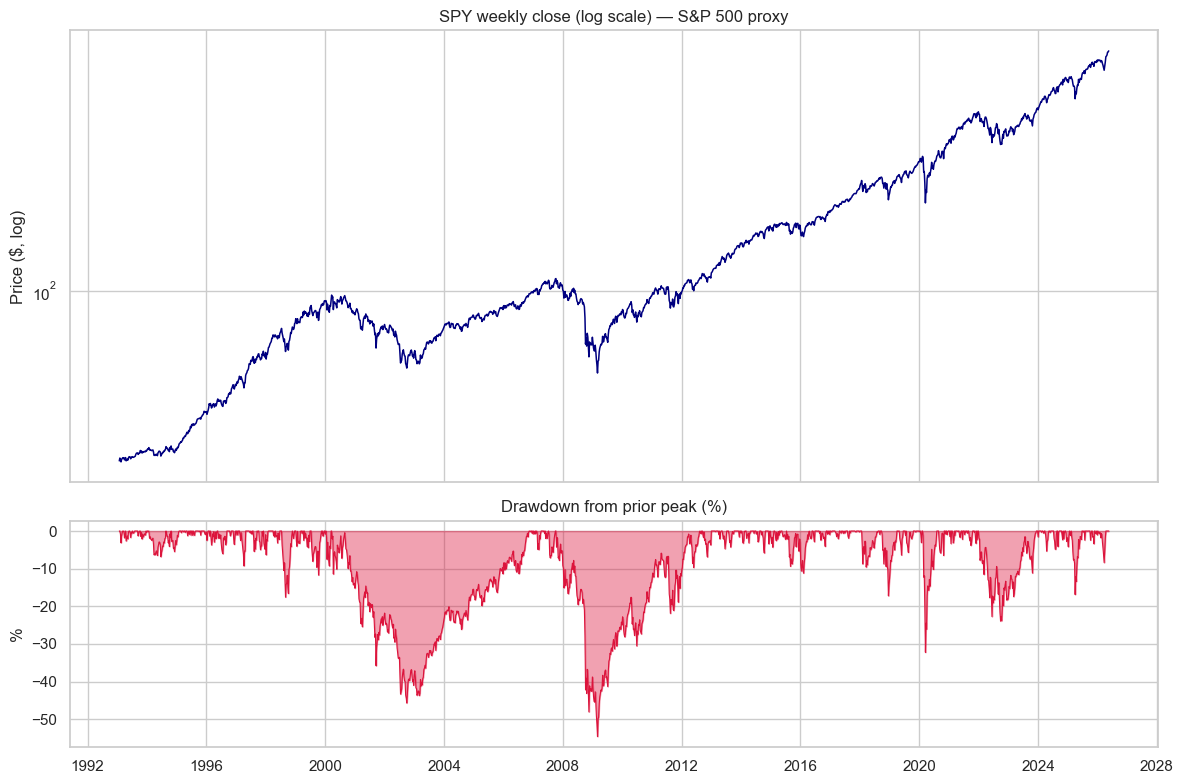

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(px.index, px, color="navy", lw=1.1)
axes[0].set_yscale("log")
axes[0].set_title("SPY weekly close (log scale) — S&P 500 proxy")
axes[0].set_ylabel("Price ($, log)")

dd = m.drawdown(px) * 100
axes[1].fill_between(dd.index, dd, 0, color="crimson", alpha=0.4)
axes[1].plot(dd.index, dd, color="crimson", lw=0.8)
axes[1].set_title("Drawdown from prior peak (%)")
axes[1].set_ylabel("%")

plt.tight_layout()
plt.show()

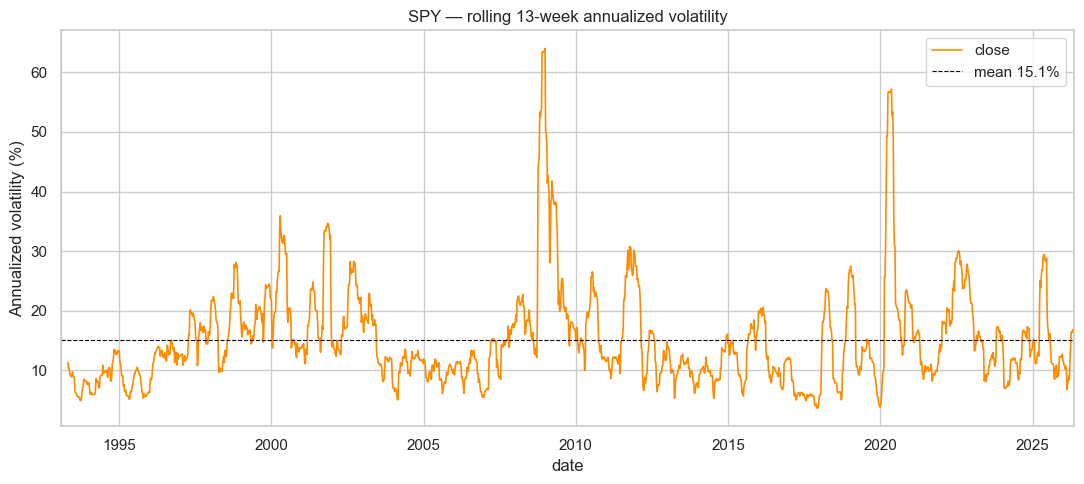

In [13]:
rv = m.rolling_volatility(wk_ret, window=13, periods_per_year=52) * 100

ax = rv.plot(color="darkorange", lw=1.2)
ax.axhline(rv.mean(), color="black", ls="--", lw=0.8, label=f"mean {rv.mean():.1f}%")
ax.set_title("SPY — rolling 13-week annualized volatility")
ax.set_ylabel("Annualized volatility (%)")
ax.legend()
plt.tight_layout()
plt.show()

### 5b. Monthly returns heatmap

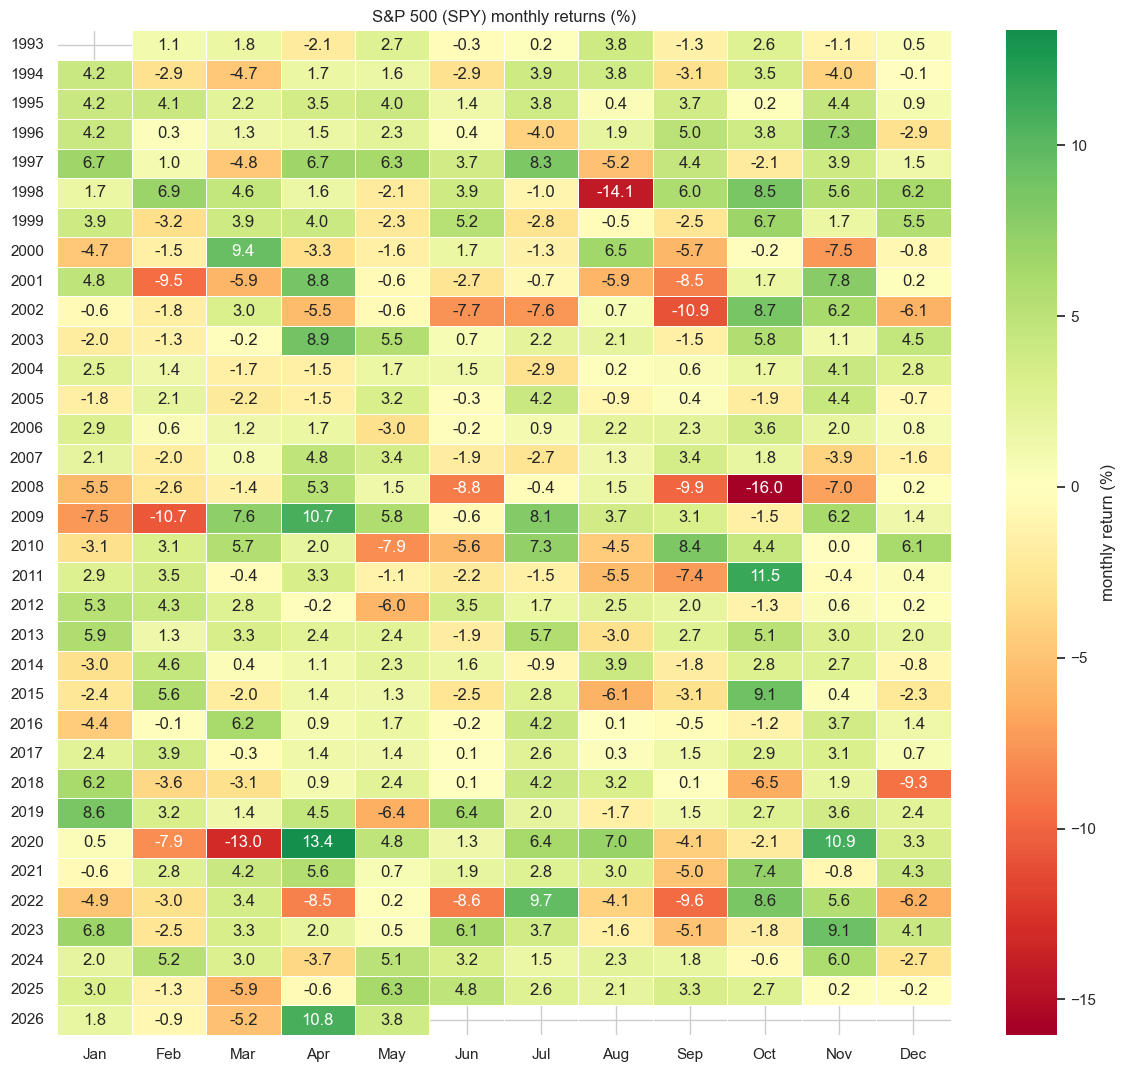

In [14]:
mret = m.simple_returns(spy_m["close"]).dropna() * 100
tbl = mret.to_frame("ret")
tbl["year"] = tbl.index.year
tbl["month"] = tbl.index.month
pivot = tbl.pivot_table(index="year", columns="month", values="ret")

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
pivot.columns = [month_names[c - 1] for c in pivot.columns]

plt.figure(figsize=(12, max(6, len(pivot) * 0.32)))
sns.heatmap(pivot, annot=True, fmt=".1f", center=0, cmap="RdYlGn",
            linewidths=0.4, cbar_kws={"label": "monthly return (%)"})
plt.title("S&P 500 (SPY) monthly returns (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Recap

Same analysis, swappable data source. `autoquant.get_adapter("yfinance" | "alphavantage")`
returns an object with a uniform interface (`get_daily`, `get_quote`, `get_weekly`,
`get_close_prices`, …), so nothing downstream changes when you switch providers.